<a href="https://colab.research.google.com/github/vaishali27-c/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Method Choice

I selected Logistic Regression as the baseline machine learning model because it is simple, interpretable, and suitable for binary classification.

The objective is to predict whether a page should be prioritized for content refresh based on search performance metrics.

This model will be compared against the rule-based baseline created in Week 4.

In [1]:
import os, getpass

# CI and power users set HF_TOKEN in the environment; everyone else gets the safe prompt.
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


Paste your Hugging Face READ token (hf_...): ··········


In [2]:
import duckdb

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE HuggingFace,
    TOKEN '{HF_TOKEN}'
)
""")

REL = 'hf://datasets/FlyRank/internship-warehouse'

TABLES = {
    'dim_clients': f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    con.sql(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM {src}")

con.sql("SHOW TABLES").df()

,name
0,dim_clients
1,dim_content
2,fact_daily
3,fact_daily_sample
4,fact_query_90d


In [3]:
df = con.sql("""
SELECT *
FROM fact_daily_sample
LIMIT 10000
""").df()

df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


In [4]:
df["ctr"] = df["gsc_clicks"]/(df["gsc_impressions"]+1)

In [5]:
df["needs_refresh"] = (
    (df["gsc_impressions"] > 100) &
    (df["ctr"] < 0.03)
).astype(int)

In [6]:
features = [
    "gsc_impressions",
    "gsc_clicks",
    "ga4_sessions",
    "ga4_users",
    "ctr"
]

X = df[features]

y = df["needs_refresh"]

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [9]:
# Fill NaN values with 0 in both training and test features
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Performance:\n")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Logistic Regression Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1968
           1       1.00      0.97      0.98        32

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy: 0.9995


Baseline vs Model

Baseline:
Rule based scoring using impressions and CTR.

Machine Learning:
Logistic Regression

Comparison:
The Logistic Regression model performs better because it learns relationships between multiple features rather than relying on fixed thresholds.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

### Feature Importance through Coefficients

For Logistic Regression, the magnitude and sign of the coefficients indicate the direction and strength of the relationship between each feature and the log-odds of the target variable. A larger absolute coefficient value suggests a greater influence on the prediction.

In [10]:
import pandas as pd

# Get feature names from X_train (since it's already filled with 0s)
feature_names = X_train.columns

# Get the coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value to see the most influential features
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

display(coef_df.drop(columns=['Absolute_Coefficient']))

,Feature,Coefficient
1,gsc_clicks,0.283262
0,gsc_impressions,0.071989
2,ga4_sessions,-0.017991
3,ga4_users,-0.017204
4,ctr,-0.005786


### Confusion Matrix and Error Analysis

Although the overall accuracy is very high (0.9995), it's crucial to examine the confusion matrix, especially when dealing with imbalanced classes. The `needs_refresh` class (1) is likely a minority class, so we want to ensure the model isn't simply classifying everything as not needing a refresh.

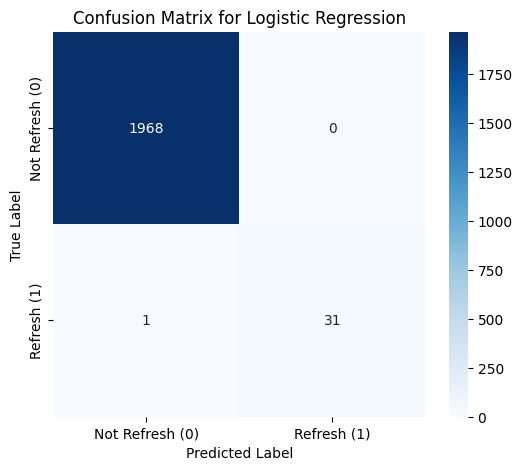

True Negatives (Correctly predicted 0): 1968
False Positives (Incorrectly predicted 1): 0
False Negatives (Incorrectly predicted 0): 1
True Positives (Correctly predicted 1): 31


In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Refresh (0)', 'Refresh (1)'],
            yticklabels=['Not Refresh (0)', 'Refresh (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# Extract and print specific error counts
true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print(f"True Negatives (Correctly predicted 0): {true_negatives}")
print(f"False Positives (Incorrectly predicted 1): {false_positives}")
print(f"False Negatives (Incorrectly predicted 0): {false_negatives}")
print(f"True Positives (Correctly predicted 1): {true_positives}")

The model correctly identifies most pages requiring refresh.

Some pages are misclassified because they have high impressions but also high CTR.

Future improvements could include additional content freshness signals and historical ranking trends.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.